# 🌸 Iris Flower Classification using K-Nearest Neighbors

In this project, I use the **K-Nearest Neighbors (KNN)** algorithm to classify Iris flowers into different species based on their physical features.

The main goal is to practice the basic workflow of a **Machine Learning classification problem**, including data exploration, feature scaling, model training, prediction, and evaluation.


## 📥 Import Libraries and Load Dataset

First, I import the required libraries and load the Iris dataset using Pandas.


In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import preprocessing

## 🔎 Data Exploration

I start by inspecting the first rows of the dataset to understand its structure and the available features.


In [34]:
df = pd.read_csv('iris.csv')
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


## 📊 Target Class Distribution

I check the number of samples belonging to each target class to understand the distribution of the dataset.


In [35]:
df['target'].value_counts()

target
0    50
1    50
2    50
Name: count, dtype: int64

## 📈 Feature Visualization

I visualize the distribution of **Sepal Length** using a histogram to get a better understanding of the feature values.


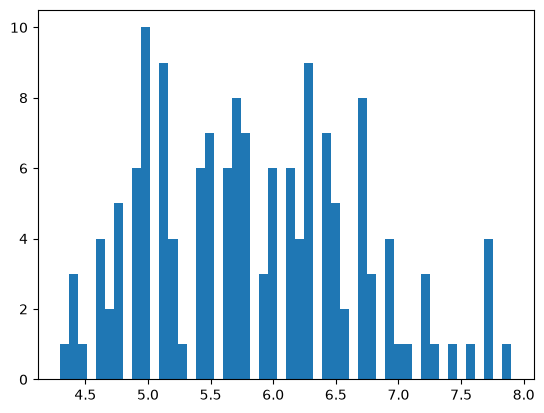

In [36]:
plt.hist(df['sepal length (cm)'] , bins = 50)
plt.show()

## 🧩 Dataset Features

The dataset contains four numerical features that will be used to predict the target class:

* Sepal Length
* Sepal Width
* Petal Length
* Petal Width

The `target` column represents the class of the Iris flower.


In [37]:
df.columns

Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'target'],
      dtype='str')

## 🎯 Features and Target

I separate the dataset into:

* **X:** input features used by the model
* **Y:** target variable that the model needs to predict


In [38]:
X = df[['sepal length (cm)' , 'sepal width (cm)' , 'petal length (cm)' , 'petal width (cm)']].values
X[0:5]

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2]])

In [39]:
Y = df['target'].values
Y[0:5]

array([0, 0, 0, 0, 0])

## ⚖️ Feature Scaling

KNN is based on distances between data points. Therefore, features with different scales can affect the distance calculation.

I use **StandardScaler** to standardize the feature values before training the model.


In [40]:
print(X[0:5])
scaler = preprocessing.StandardScaler().fit(X)
X = scaler.transform(X.astype(float))
X[0:5]

[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]


array([[-0.90068117,  1.01900435, -1.34022653, -1.3154443 ],
       [-1.14301691, -0.13197948, -1.34022653, -1.3154443 ],
       [-1.38535265,  0.32841405, -1.39706395, -1.3154443 ],
       [-1.50652052,  0.09821729, -1.2833891 , -1.3154443 ],
       [-1.02184904,  1.24920112, -1.34022653, -1.3154443 ]])

## ✂️ Train/Test Split

I split the dataset into training and testing sets.

* **80%** of the data is used for training.
* **20%** of the data is used for testing.

The training set is used to train the model, while the test set is used to evaluate its performance on unseen data.


In [73]:
from sklearn.model_selection import train_test_split
X_train , X_test , Y_train , Y_test = train_test_split(X , Y , test_size=0.2 , random_state = 42)

print('Train set: ' , X_train.shape , Y_train.shape)
print('Test set: ' , X_test.shape , Y_test.shape)

Train set:  (120, 4) (120,)
Test set:  (30, 4) (30,)


## 🤖 Building the KNN Model

I use the **K-Nearest Neighbors (KNN)** algorithm for this classification problem.

KNN predicts the class of a new data point based on the classes of its nearest neighboring data points.

The `K` parameter determines how many neighbors are considered when making a prediction.


In [74]:
from sklearn.neighbors import KNeighborsClassifier

## 🏋️ Model Training

The KNN classifier is trained using the training data.

The model learns the relationship between the input features and their corresponding target classes.


In [75]:
k = 4
neigh = KNeighborsClassifier(n_neighbors = k).fit(X_train , Y_train)
neigh

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",4
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](3,)","[0,1,2]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


## 🔮 Making Predictions

After training the model, I use the test data to predict the Iris flower classes.


In [76]:
yhat = neigh.predict(X_test)
yhat[0:5]

array([1, 0, 2, 1, 1])

## 📊 Model Evaluation

I evaluate the model by comparing its predictions with the actual target values from the test set.

The main metric used here is **Accuracy**, which represents the proportion of correctly classified samples.


In [77]:
from sklearn import metrics

print("Train set Accuracy: ", metrics.accuracy_score(Y_train, neigh.predict(X_train)))
print("Test set Accuracy: ", metrics.accuracy_score(Y_test, yhat))

Train set Accuracy:  0.9583333333333334
Test set Accuracy:  1.0


## 🔍 Testing Different Values of K

The value of `K` can affect the performance of a KNN model.

I test different values of `K` and compare their accuracy scores to observe how the model performance changes.


In [80]:
ks = 10 
mean_acc = np.zeros((ks-1))
std_acc = np.zeros((ks-1))

for n in range(1 , ks):

    neigh = KNeighborsClassifier(n_neighbors= n).fit(X_train , Y_train)
    yhat = neigh.predict(X_test)
    mean_acc[n-1] = metrics.accuracy_score(Y_test, yhat)

    std_acc[n-1]=np.std(yhat==Y_test)/np.sqrt(yhat.shape[0])

mean_acc

array([0.96666667, 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        ])

## 📈 K vs Accuracy

The following plot shows the relationship between the value of `K` and the model's accuracy on the test set.

This helps visualize how the choice of `K` affects the classification performance.


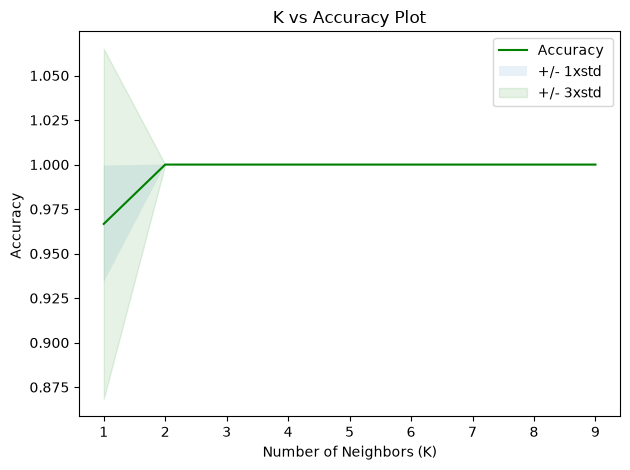

In [79]:
plt.plot(range(1,ks),mean_acc,'g')
plt.fill_between(range(1,ks),mean_acc - 1 * std_acc,mean_acc + 1 * std_acc, alpha=0.10)
plt.fill_between(range(1,ks),mean_acc - 3 * std_acc,mean_acc + 3 * std_acc, alpha=0.10,color="green")
plt.legend(('Accuracy ', '+/- 1xstd','+/- 3xstd'))
plt.ylabel('Accuracy ')
plt.xlabel('Number of Neighbors (K)')
plt.title('K vs Accuracy Plot')
plt.tight_layout()
plt.show()

## 📝 Conclusion

In this project, I built an Iris flower classification model using the **K-Nearest Neighbors (KNN)** algorithm.

I practiced the main steps of a Machine Learning classification workflow, including:

* Data exploration
* Feature and target selection
* Train/Test splitting
* Feature scaling
* KNN model training
* Prediction
* Model evaluation
* Testing different values of `K`

This project helped me strengthen my understanding of **classification and the K-Nearest Neighbors algorithm** using Scikit-learn.
